In [18]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer, Conv2D, Dense, \
                            Flatten, Dropout, MaxPool2D, BatchNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.backend import clear_session
from tensorflow.keras.datasets.cifar10 import load_data

## Data retreival
Download the dataset from keras

In [19]:
(X_train, y_train), (X_test, y_test) = load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [20]:
# labels encoding
labels = ['airplane', 'automobi]e', 'bird', 'cat', 'deer', \
          'dog', 'frog', 'horse', 'ship', 'truck']

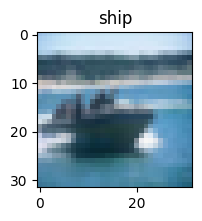

In [21]:
# random image visualization
plt.figure(figsize=(2, 3))
index = np.random.choice(range(X_train.shape[0]))
plt.imshow(X_train[index])
plt.title(labels[y_train[index][0]]);

## Preprocessing
Normalization and flattening

In [22]:
X_train, X_test = X_train/255., X_test/255.
y_train, y_test = y_train.flatten(), y_test.flatten()

## Building the Neural Network
We once again use AlexNet Convolutional Neural Network structure as example for this exercise

In [23]:
clear_session()
w_init = tf.keras.initializers.RandomNormal(stddev=0.01)
alex_net = Sequential([
    InputLayer(input_shape=(32, 32, 3)),

    Conv2D(96, kernel_size=(3, 3), strides=(1, 1), bias_initializer='zeros',
           kernel_initializer=w_init,activation='relu'),

    BatchNormalization(),

    MaxPool2D(pool_size=(3, 3), strides=(2, 2)),

    Conv2D(256, kernel_size=(3, 3), strides=(1, 1), bias_initializer='ones',
           kernel_initializer=w_init, padding='same', activation='relu'),

    BatchNormalization(),

    MaxPool2D(pool_size=(3, 3), strides=(2, 2)),

    Conv2D(384, kernel_size=(3, 3), strides=(1, 1), bias_initializer='zeros',
           kernel_initializer=w_init, padding='same', activation='relu'),

    Conv2D(384, kernel_size=(3, 3), strides=(1, 1), bias_initializer='ones',
           kernel_initializer=w_init, padding='same', activation='relu'),

    Conv2D(256, kernel_size=(3, 3), strides=(1, 1), bias_initializer='ones',
           kernel_initializer=w_init, padding='same', activation='relu'),

    MaxPool2D(pool_size=(3, 3), strides=(2, 2)),

    Flatten(),

    Dense(4096, kernel_initializer=w_init, bias_initializer='ones', activation='relu'),

    Dropout(.5),

    Dense(4096, kernel_initializer=w_init, bias_initializer='ones', activation='relu'),

    Dropout(.5),
    
    Dense(1000, kernel_initializer=w_init, bias_initializer='zeros', activation='softmax'),
])

In [24]:
alex_net.compile(optimizer="adam",
                 loss = "sparse_categorical_crossentropy",
                 metrics = ["accuracy"]
                 )


In [25]:
history = alex_net.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 463s 295ms/step - accuracy: 0.3422 - loss: 1.8947 - val_accuracy: 0.4151 - val_loss: 1.6485
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 665s 426ms/step - accuracy: 0.5059 - loss: 1.4109 - val_accuracy: 0.5512 - val_loss: 1.3043
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 762s 487ms/step - accuracy: 0.5716 - loss: 1.2522 - val_accuracy: 0.5175 - val_loss: 1.5308
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 443s 283ms/step - accuracy: 0.6091 - loss: 1.1623 - val_accuracy: 0.5387 - val_loss: 1.3560
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 448s 287ms/step - accuracy: 0.6372 - loss: 1.0834 - val_accuracy: 0.6036 - val_loss: 1.1541


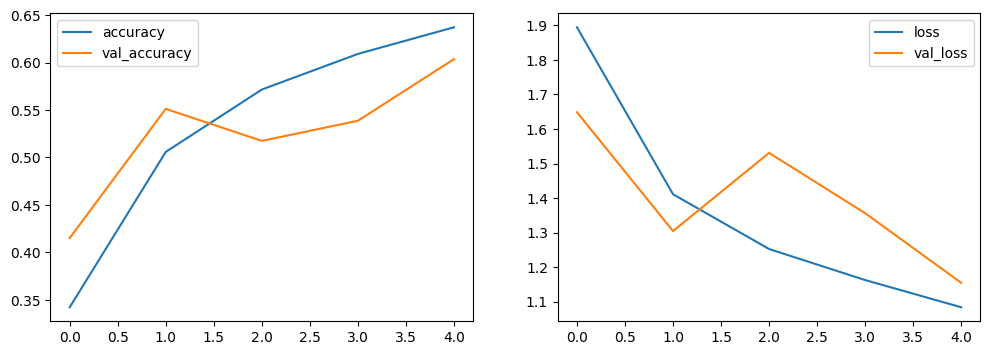

In [26]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend();

## Improve the Network

The following network has a much more regular and simpler structure than the actual AlexNet built above.
The size of the Dense layers were adjusted accordingly to the dataset.

In [27]:
clear_session()
cnn_improved = Sequential([
    InputLayer(input_shape=(32, 32, 3)),
    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),  

    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding="same"), 
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax'),
])

cnn_improved.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Let's add a bit of Data Augmentation to further improve the training process

In [28]:
batch_size = 128
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)

In [29]:
train_generator = data_generator.flow(X_train, y_train, batch_size)
steps_per_epoch = X_train.shape[0] // batch_size

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

history2 = cnn_improved.fit(
    train_generator,
    validation_data=(X_test, y_test), 
    steps_per_epoch=steps_per_epoch, 
    epochs=50,
    callbacks=[lr_callback]
)

Epoch 1/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 95s 238ms/step - accuracy: 0.3963 - loss: 1.7151 - val_accuracy: 0.3182 - val_loss: 2.1374 - learning_rate: 0.0010
Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4062 - loss: 1.4626 - val_accuracy: 0.3235 - val_loss: 2.0996 - learning_rate: 0.0010
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 96s 246ms/step - accuracy: 0.5365 - loss: 1.2904 - val_accuracy: 0.4962 - val_loss: 1.5979 - learning_rate: 0.0010
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5547 - loss: 1.2449 - val_accuracy: 0.4986 - val_loss: 1.5445 - learning_rate: 0.0010
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 98s 252ms/step - accuracy: 0.6031 - loss: 1.1186 - val_accuracy: 0.6426 - val_loss: 1.0266 - learning_rate: 0.0010
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5859 - loss: 1.0110 - val_accuracy: 0.6421 - val_loss: 1.0348 - learning_rate: 0.0010
Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 99s 254ms/step - accuracy: 0.6534 - 

In [30]:
# saved the trained weights locally for future reuse
cnn_improved.save_weights('cnn_improved.weights.h5')
with open("cnn_improved.pkl", "wb") as f:
    pickle.dump(history2.history, f)

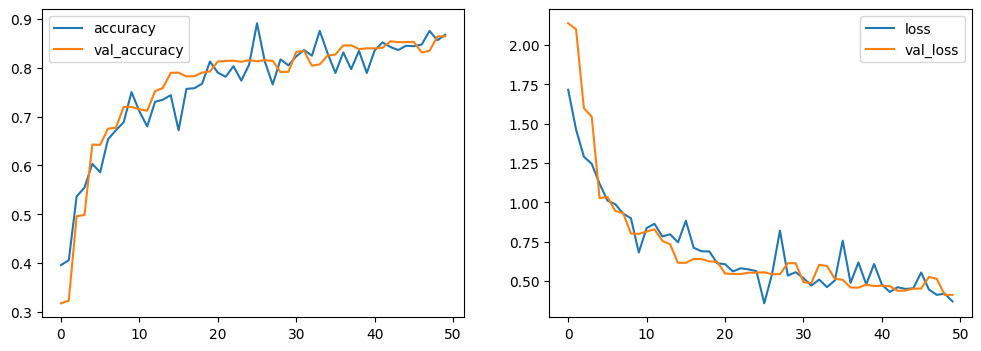

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(history2.history["accuracy"], label = "accuracy")
plt.plot(history2.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history2.history["loss"], label = "loss")
plt.plot(history2.history["val_loss"], label = "val_loss")
plt.legend();

In [32]:
cnn_improved.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8641 - loss: 0.4127


[0.412661075592041, 0.8640999794006348]

In [33]:
# load the saved weights into a model
cnn_improved.load_weights("cnn_improved.weights.h5")
history_loaded = pickle.load(open("cnn_improved.pkl", "rb"))

In [34]:
cnn_improved.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8641 - loss: 0.4127


[0.412661075592041, 0.8640999794006348]